In [1]:
import os
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
base_path = 'data'
datasets = ["borealtc", "vulpi"]
imu_columns = ["time", "wx", "wy", "wz", "ax", "ay", "az"]

In [6]:
def load_imu_data(dataset, terrain, file_name="imu_00.csv", base_path="data"):
    path = os.path.join(base_path, dataset, terrain, file_name)
    if os.path.exists(path):
        df = pd.read_csv(path)
        df["terrain"] = terrain
        df["dataset"] = dataset
        return df

In [7]:
def get_terrains(dataset): 
    path = os.path.join(base_path, dataset)
    return sorted([f for f in os.listdir(path) if os.path.isdir(os.path.join(path,f))])

In [9]:
first_imu_file = {
    "borealtc": "imu_00.csv",
    "vulpi": "imu_1.csv"
}

Dataset: borealtc Terrain: ['ASPHALT', 'FLOORING', 'ICE', 'MIXED', 'SANDY_LOAM', 'SNOW']


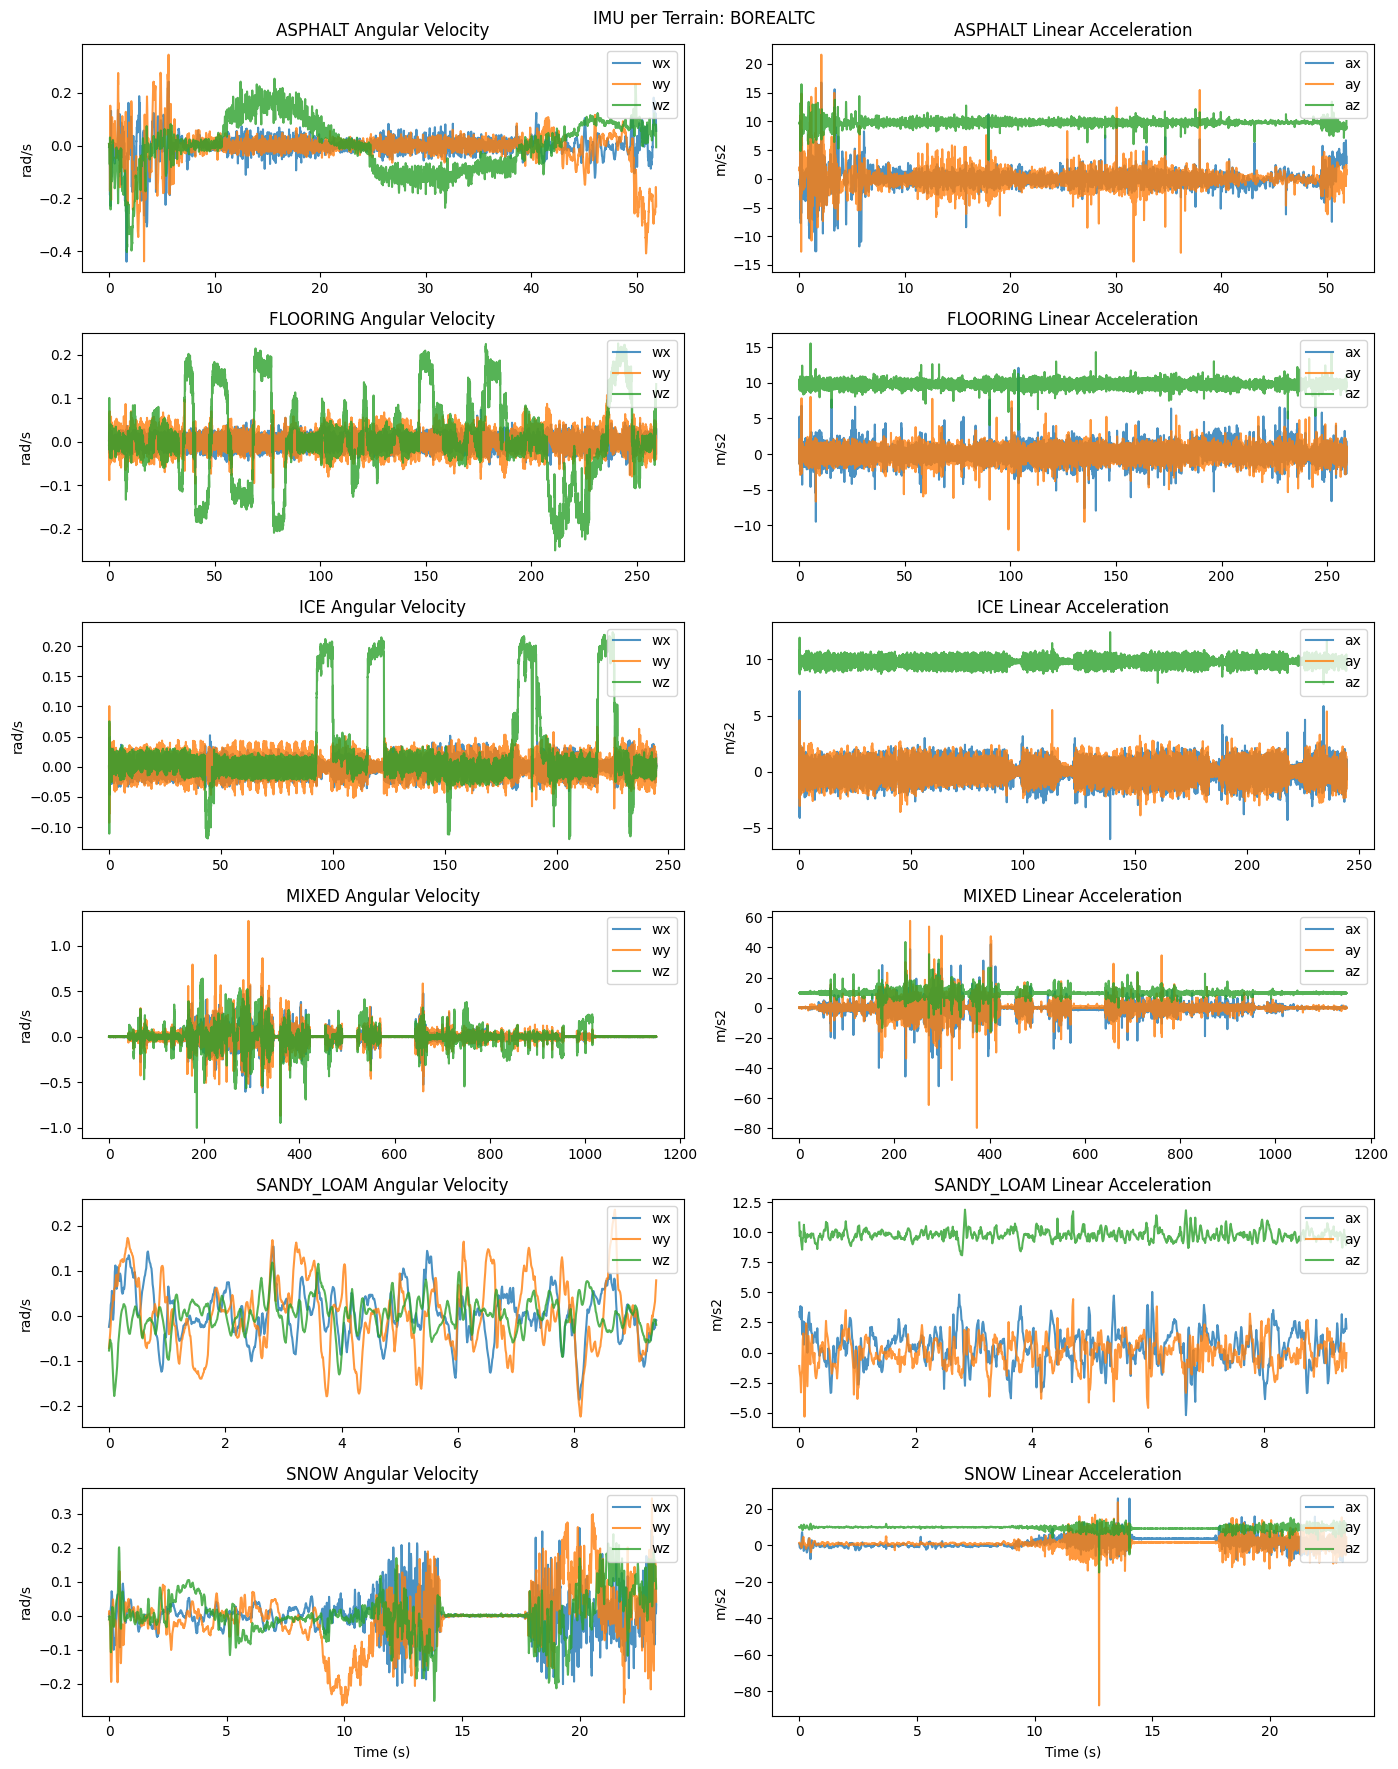

Dataset: vulpi Terrain: ['CONCRETE', 'DIRT_ROAD', 'PLOUGHED', 'UNPLOUGHED']


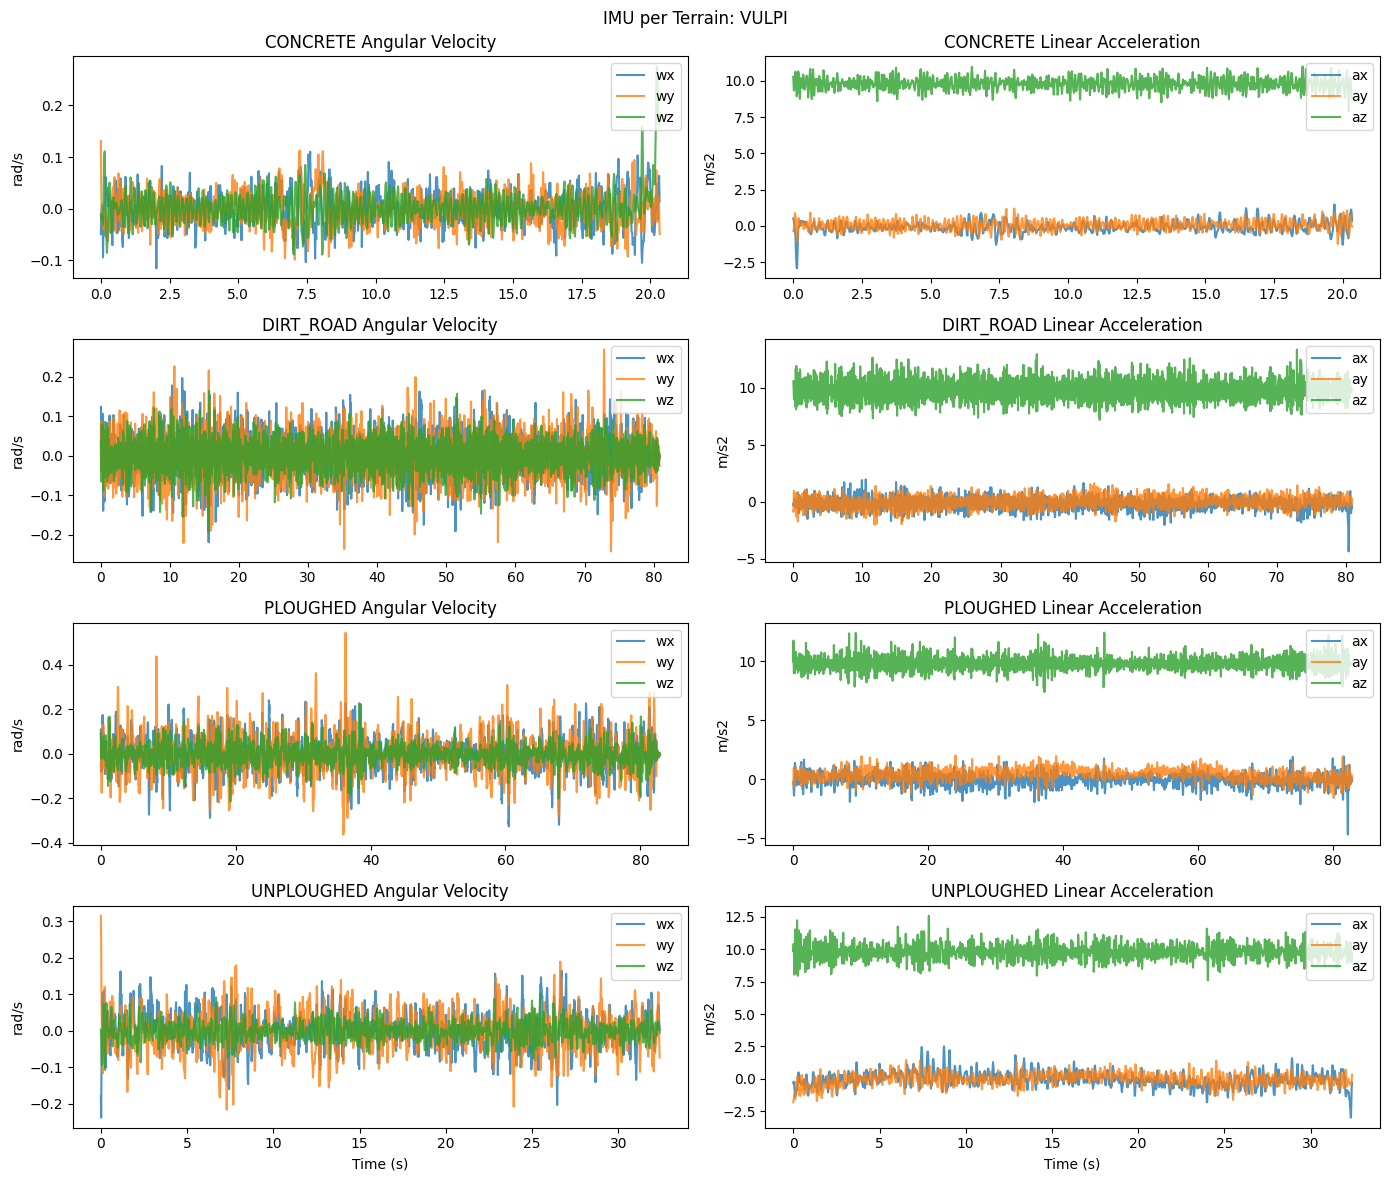

In [12]:
for dataset in datasets: 
    terrains = get_terrains(dataset)
    print(f"Dataset: {dataset} Terrain: {terrains}")

    n = len(terrains)
    fig, axs = plt.subplots(n, 2, figsize=(14,3*n), sharex = False)
    fig.suptitle(f"IMU per Terrain: {dataset.upper()}")

    for i, terrain in enumerate(terrains): 
        df = load_imu_data(dataset, terrain, file_name=first_imu_file[dataset])

        axs[i, 0].plot(df["time"], df["wx"], label="wx", alpha=0.8)
        axs[i, 0].plot(df["time"], df["wy"], label="wy", alpha=0.8)
        axs[i, 0].plot(df["time"], df["wz"], label="wz", alpha=0.8)
        axs[i, 0].set_title(f"{terrain} Angular Velocity")
        axs[i, 0].set_ylabel("rad/s")
        axs[i, 0].legend(loc="upper right")

        axs[i, 1].plot(df["time"], df["ax"], label="ax", alpha=0.8)
        axs[i, 1].plot(df["time"], df["ay"], label="ay", alpha=0.8)
        axs[i, 1].plot(df["time"], df["az"], label="az", alpha=0.8)
        axs[i, 1].set_title(f"{terrain} Linear Acceleration")
        axs[i, 1].set_ylabel("m/s2")
        axs[i, 1].legend(loc="upper right")
    
    for ax in axs[-1, :]: 
        ax.set_xlabel("Time (s)")

    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.show()